## Set-up

### Imports

In [1]:
import torch

import os
import time

from pathlib import Path
import glob

import numpy as np
import pandas as pd

import supervision as sv
import cv2

import matplotlib.pyplot as plt
import seaborn as sn

### Functions

In [2]:
def show_anns(anns):
    if len(anns) == 0:
        return
    sorted_anns = sorted(anns, key=(lambda x: x['area']), reverse=True)
    ax = plt.gca()
    ax.set_autoscale_on(False)

    img = np.ones((sorted_anns[0]['segmentation'].shape[0], sorted_anns[0]['segmentation'].shape[1], 4))
    img[:,:,3] = 0
    for ann in sorted_anns:
        m = ann['segmentation']
        color_mask = np.concatenate([np.random.random(3), [0.35]])
        img[m] = color_mask
    ax.imshow(img)

In [3]:
from datetime import datetime

def mk_timestampedfolder(path, basename, dtime=None):
    if not dtime:
        dtime = datetime.now().strftime('%Y%m%d%H%M')
    
    token = str(hex(int(dtime[2:])))[2:]
    out_folder = os.path.join(path, token + '_' + basename)

    try:
        os.makedirs(out_folder)
    except FileExistsError:
        if not os.listdir(out_folder):
            print('Using existing empty folder')
        else:
            raise
            
    return out_folder

In [4]:
def save_masks(anns, folder_path):
    if len(anns) == 0:
        return
    sorted_anns = sorted(anns, key=(lambda x: x['area']), reverse=True)
    num = len(str(len(sorted_anns)))

    try:
        os.makedirs(folder_path)
    except FileExistsError:
        if not os.listdir(folder_path):
            print('Using existing empty folder')
        else:
            print('Using existing NON EMPTY folder')
    
    for idx, ann in enumerate(sorted_anns):
        m = ann['segmentation']
        mask = np.uint8(m)
        
        number = str(idx).zfill(num)
        plt.imsave(os.path.join(folder_path, 'mask_' + number + '.png'), mask)        

In [5]:
def filter_borders(anns):
    sorted_anns = sorted(anns, key=(lambda x: x['area']), reverse=True)
    keep_masks = []

    for ann in sorted_anns:
        m = ann['segmentation']
        mask = np.uint8(m)

        borders = sum(mask[0,:]) + sum(mask[:,0]) + sum(mask[-1,:]) + sum(mask[:, -1])

        if not borders:
            keep_masks.append(ann)            

    return keep_masks

In [6]:
# Beware, this function does not update all the keys of the mask dictionnary when merging masks
def compare_masks(anns):
    
    sorted_anns = sorted(anns, key=(lambda x: x['area']), reverse=True)
    remove = []

    for idx, ann_i in enumerate(sorted_anns):
        mask_i = ann_i['segmentation']
        temp_mask = mask_i
        
        for jdx, ann_j in enumerate(sorted_anns[idx+1:]):
            mask_j = ann_j['segmentation']
            
            mask_comp = mask_i & mask_j
            comp = sum(sum(mask_comp))

            if comp:
                # print(f"{idx} and {jdx+idx+1} share {comp} pixels")  
                remove.append(jdx+idx+1)

        if not np.all(temp_mask == mask_i):
            sorted_anns[idx]['segmentation'] = temp_mask
            sorted_anns[idx]['area'] = sum(sum(temp_mask))

    # print(remove)
    keep_masks = [mask for idx, mask in enumerate(sorted_anns) if idx not in remove]
    return keep_masks
        

### SAM Configuration

In [7]:
import sys
sys.path.append("..")
from segment_anything import sam_model_registry, SamAutomaticMaskGenerator, SamPredictor

# sam_checkpoint = "sam_checkpoints/sam_vit_b_01ec64.pth"
# model_type = "vit_b"

sam_checkpoint = "sam_checkpoints/sam_vit_l_0b3195.pth"
model_type = "vit_l"

# sam_checkpoint = "checkpoints/sam_vit_h_4b8939.pth"
# model_type = "vit_h"

device = "cpu" # cuda

sam = sam_model_registry[model_type](checkpoint=sam_checkpoint)
sam.to(device=device)

Sam(
  (image_encoder): ImageEncoderViT(
    (patch_embed): PatchEmbed(
      (proj): Conv2d(3, 1024, kernel_size=(16, 16), stride=(16, 16))
    )
    (blocks): ModuleList(
      (0): Block(
        (norm1): LayerNorm((1024,), eps=1e-06, elementwise_affine=True)
        (attn): Attention(
          (qkv): Linear(in_features=1024, out_features=3072, bias=True)
          (proj): Linear(in_features=1024, out_features=1024, bias=True)
        )
        (norm2): LayerNorm((1024,), eps=1e-06, elementwise_affine=True)
        (mlp): MLPBlock(
          (lin1): Linear(in_features=1024, out_features=4096, bias=True)
          (lin2): Linear(in_features=4096, out_features=1024, bias=True)
          (act): GELU()
        )
      )
      (1): Block(
        (norm1): LayerNorm((1024,), eps=1e-06, elementwise_affine=True)
        (attn): Attention(
          (qkv): Linear(in_features=1024, out_features=3072, bias=True)
          (proj): Linear(in_features=1024, out_features=1024, bias=True)
        

In [8]:
# mask_generator = SamAutomaticMaskGenerator(sam)
mask_generator = SamAutomaticMaskGenerator(model=sam, min_mask_region_area = 10000 )
                                         

## Run on single image and save all masks

In [9]:
IMG_PATH = 'test_images/'
IMG_NAME = 'books.jpg'
OUT_PATH = 'out/'

In [10]:
image_path = os.path.join(IMG_PATH,IMG_NAME)
image = cv2.imread(image_path)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

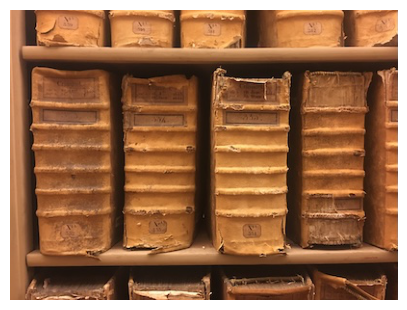

In [11]:
plt.figure(figsize=(5,5))
plt.imshow(image)
plt.axis('off')
plt.show()

In [12]:
masks = mask_generator.generate(image)
print(len(masks))

87


In [13]:
save_masks(masks, OUT_PATH)

Using existing NON EMPTY folder


## Filter masks based on size

87


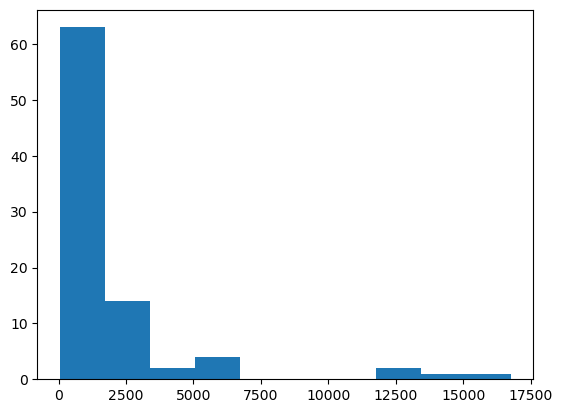

In [14]:
areas = [mask['area'] for mask in masks]
plt.hist(areas)
print(len(masks))

In [15]:
keep_masks = [mask for mask in masks if mask['area']>10000]
keep_areas = [mask['area'] for mask in keep_masks]
print(len(keep_masks))

save_folder = mk_timestampedfolder(OUT_PATH, 'filtered')
save_masks(keep_masks, save_folder)

4
Using existing empty folder


## Filter masks based on size

87


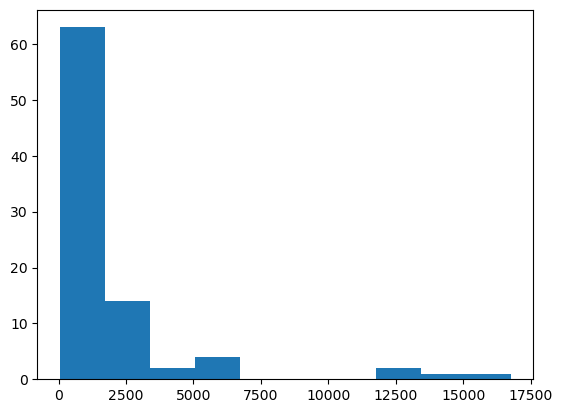

In [17]:
areas = [mask['area'] for mask in masks]
plt.hist(areas)
print(len(masks))

In [18]:
keep_masks = [mask for mask in masks if mask['area']>10000]
keep_areas = [mask['area'] for mask in keep_masks]
print(len(keep_masks))

save_folder = mk_timestampedfolder(OUT_PATH, 'filtered')
save_masks(keep_masks, save_folder)

4


FileExistsError: [Errno 17] File exists: 'out/9b48d59e_filtered'

## Run on a full folder
Output will be saved in time-token folder

In [20]:
parent_folder = '/Users/csc/Documents/Data/Reliures/AN3'
images_folder = 'shelves'
# parent_folder = '/Users/csc/Documents/Data/Reliures/Insectes'
# images_folder = 'mosquitoes'
out_base = 'masks'
anns_base = 'annotations'

In [21]:
now = datetime.now().strftime('%Y%m%d%H%M')
print(f"Current token is {str(hex(int(now[2:])))[2:]}")
      
out_folder = mk_timestampedfolder(parent_folder, out_base, now)
anns_folder = mk_timestampedfolder(parent_folder, anns_base, now)

images_folder = os.path.join(parent_folder, images_folder)
image_files = glob.glob(images_folder + '/*.jpg')

start_time = time.time()
mid_time = start_time
print(f"Start time: {time.ctime(start_time)}")

for idx, filename in enumerate(image_files[:10]):
# for idx, filename in enumerate(image_files):
    file = Path(filename).stem
    
    print(f"Currently working on image number {idx}: {filename}")

    full_path = os.path.join(images_folder, filename)
    masks_folder = os.path.join(out_folder, file)
    
    image_bgr = cv2.imread(full_path)
    image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)
    
    masks = mask_generator.generate(image_rgb)
    keep_masks = [mask for mask in masks if mask['area']>10000]
    keep_masks = filter_borders(keep_masks)
    keep_masks = compare_masks(keep_masks)

    mask_annotator = sv.MaskAnnotator(color_lookup=sv.ColorLookup.INDEX)
    detections = sv.Detections.from_sam(sam_result=keep_masks)
    annotated_image = mask_annotator.annotate(scene=image_bgr.copy(), detections=detections)
    cv2.imwrite(os.path.join(anns_folder, 'anns_' + file + '.jpg'), annotated_image)

    save_masks(keep_masks, masks_folder)
    
    print(f"Time taken: {time.time() - mid_time:.2f} seconds")
    mid_time = time.time()

end_time = time.time()
print(f"End time: {time.ctime(end_time)}")
print(f"Total execution time: {((end_time - start_time)/60):.2f} minutes")

Current token is 9b48d5c8
Start time: Sun May 24 18:00:02 2026
Currently working on image number 0: /Users/csc/Documents/Data/Reliures/AN3/shelves/shelf_016.jpg
Time taken: 43.05 seconds
Currently working on image number 1: /Users/csc/Documents/Data/Reliures/AN3/shelves/shelf_002.jpg
Time taken: 43.29 seconds
Currently working on image number 2: /Users/csc/Documents/Data/Reliures/AN3/shelves/shelf_003.jpg
Time taken: 44.06 seconds
Currently working on image number 3: /Users/csc/Documents/Data/Reliures/AN3/shelves/shelf_017.jpg
Time taken: 43.58 seconds
Currently working on image number 4: /Users/csc/Documents/Data/Reliures/AN3/shelves/shelf_029.jpg
Time taken: 42.36 seconds
Currently working on image number 5: /Users/csc/Documents/Data/Reliures/AN3/shelves/shelf_001.jpg
Time taken: 42.20 seconds
Currently working on image number 6: /Users/csc/Documents/Data/Reliures/AN3/shelves/shelf_015.jpg
Time taken: 41.28 seconds
Currently working on image number 7: /Users/csc/Documents/Data/Reliur

## Compare SAM masks with Ground Truth masks
Results will be saved in a .csv file

#### New imports

In [29]:
import csv
from PIL import Image

#### Functions

In [30]:
def gt2mask(img_path, channel = "G"):
    img = Image.open(img_path)
    channel = img.getchannel(channel)
    resized = channel.resize(SIZE, Image.LANCZOS)
    array = np.array(resized)
    mask = (array>0)
    
    return mask

In [31]:
def sam2mask(img_path, channel = "G"):
    img = Image.open(img_path)
    channel = img.getchannel(channel)
    array = np.array(channel)
    mask = (array>127)
    
    return mask

In [32]:
def iou(mask1, mask2):
    union = sum(sum(mask1 | mask2))
    intersection = sum(sum(mask1 & mask2))
    iou = intersection / union if union != 0 else 0
    
    return iou

In [33]:
def write_data2csv(data, filename):
    with open(filename, mode='w', newline='') as file:
        writer = csv.DictWriter(file, fieldnames=data[0].keys())
        writer.writeheader()
        for row in data:
            writer.writerow(row)
            
    print(f"CSV file '{filename}' successfully created.")

#### Parameters

In [35]:
parent_folder = '/Users/csc/Documents/Data/Reliures/AN3'
gt_masks = 'gt_masks'
token = '9b48d5c8'

SIZE = (400, 300) # This is necessary in case images were resized to speed up segmentation

sam_masks = token + '_masks'

#### Main

In [36]:
gt_folders = os.path.join(parent_folder, gt_masks)
sam_folders = os.path.join(parent_folder, sam_masks)

sam_folder_list = [ f.name for f in os.scandir(sam_folders) if f.is_dir() ]
gt_folder_list = [ f.name for f in os.scandir(gt_folders) if f.is_dir() ]

data = []

for curr_folder in sam_folder_list:   
    if curr_folder in gt_folder_list:
        sam_path = os.path.join(sam_folders, curr_folder)
        sam_paths_list = glob.glob(sam_path + '/*.png')

        gt_path = os.path.join(gt_folders, curr_folder)
        gt_paths_list = glob.glob(gt_path + '/*.png')

        paired_masks = []

        for curr_gt in gt_paths_list:           
            gt_mask = gt2mask(curr_gt)
           
            best_iou = 0
            best_mask = '0'

            for curr_sam in sam_paths_list:
                sam_mask = sam2mask(curr_sam)
                curr_iou = iou(gt_mask, sam_mask)

                if curr_iou > best_iou:
                    best_iou = curr_iou
                    best_mask = curr_sam

            paired_masks.append(best_mask)
            
            # Also takes care of orphaned GT masks
            row = { 'Folder': curr_folder,
                   'GroundTruth': Path(curr_gt).stem,
                   'SamMask': Path(best_mask).stem,
                   'IoU': "{:.2f}".format(best_iou)
                  }
            data.append(row)

        # Now take care of orphaned SAM masks
        sam_orphans = list(set(sam_paths_list) - set(paired_masks))
        for orphan in sam_orphans:
            row = { 'Folder': curr_folder,
                   'GroundTruth': "0",
                   'SamMask': Path(orphan).stem,
                   'IoU': "{:.2f}".format(0)
                  }
            data.append(row)
            
    else:
        print(f"No ground truth found for:   {current_folder}")

data = sorted(data, key=lambda d: d['Folder'])
outfile = os.path.join(parent_folder, sam_masks + '.csv')
write_data2csv(data, outfile)

CSV file '/Users/csc/Documents/Data/Reliures/AN3/9b48d5c8_masks.csv' successfully created.


## Analyze results from CSV file

In [37]:
# Load the CSV file
csv_file = os.path.join(parent_folder, sam_masks + '.csv')
df = pd.read_csv(csv_file)

#### Histogram of non-zero IoUs

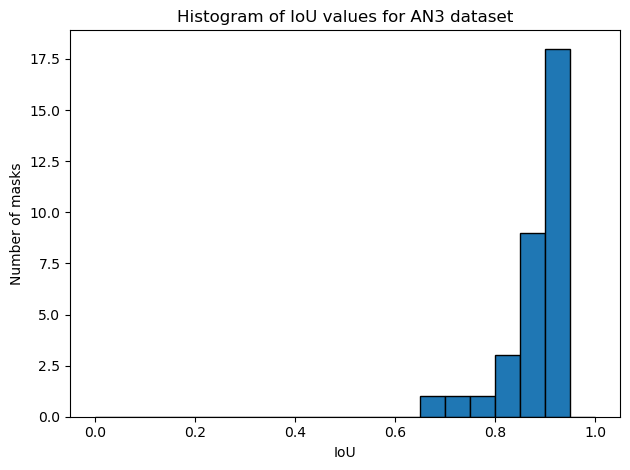

In [38]:
dataset = Path(parent_folder).stem

# Filter out 0 values
nonzeros_df = df[df['IoU'] != 0]

# Plot the histogram
plt.hist(nonzeros_df['IoU'], bins=20, range=[0,1], edgecolor= 'black')
plt.title(f"Histogram of IoU values for {dataset} dataset")
plt.xlabel('IoU')
plt.ylabel('Number of masks')

# Save the plot
histfile = os.path.join(parent_folder, 'hist_' + sam_masks + '.pdf')
plt.tight_layout()
plt.savefig(histfile, bbox_inches="tight")

#### SAM Orphans
SAM masks detected with no associated Ground Truth, these are False Positives.

In [39]:
sam_orphans = df[df['GroundTruth'] == '0'].reset_index(drop = True)
print(sam_orphans)

Empty DataFrame
Columns: [Folder, GroundTruth, SamMask, IoU]
Index: []


#### Ground Truth orphans
Ground Truth masks detected with no associated SAM masks.\
These are the False Negatives.

In [40]:
gt_orphans = df[df['SamMask'] == '0'].reset_index(drop = True)
print(gt_orphans)

      Folder GroundTruth SamMask  IoU
0  shelf_028      book_2       0  0.0


#### Confusion matrix

Text(0, 0.5, 'Number of masks')

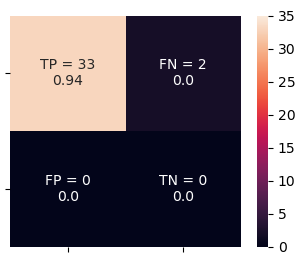

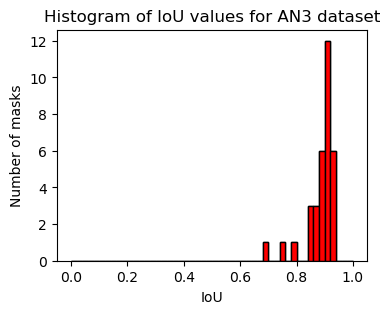

In [41]:
threshold = 0.50

total = len(df)
FP = len(df[df['GroundTruth'] == '0'])
filtered_df = df[df['GroundTruth'] != '0']

TP = len(filtered_df[filtered_df['IoU'] > threshold])
FN = len(filtered_df) - TP    

TN = 0

array = [[TP,FN],
         [FP,TN]]

labels =  [['TP = ' + str(TP) + '\n' + str(round(TP/total, 2)), 
            'FN = ' + str(FN) + '\n' + str(round(FP/total, 2))],
           ['FP = ' + str(FP) + '\n' + str(round(FP/total, 2)), 
            'TN = ' + str(TN) + '\n' + str(round(TN/total, 2))]]

df_cm = pd.DataFrame(array, range(2), range(2))

plt.figure(figsize=(4,3))
sn.heatmap(df_cm, annot=labels, fmt = "", vmax = total) 
plt.tick_params(labelbottom=False, labelleft=False)
plt.gca().set_aspect("equal")

# Save the plot
cm_file = os.path.join(parent_folder, 'cm_' + str(threshold) + '_' + sam_masks + '.pdf')
plt.tight_layout
plt.savefig(cm_file, bbox_inches="tight")

plt.figure(figsize=(4,3))
plt.hist(nonzeros_df['IoU'], bins=50, range=[0,1], edgecolor= 'black')

TPs = filtered_df[filtered_df['IoU'] > threshold]
plt.hist(TPs['IoU'], bins=50, range=[0,1], edgecolor= 'black', color = 'red')

plt.title(f"Histogram of IoU values for {dataset} dataset")
plt.xlabel('IoU')
plt.ylabel('Number of masks')

## Analyze results from CSV file

In [42]:
# Load the CSV file
csv_file = os.path.join(parent_folder, sam_masks + '.csv')
df = pd.read_csv(csv_file)

#### Histogram of non-zero IoUs

In [ ]:
dataset = Path(parent_folder).stem

# Filter out 0 values
nonzeros_df = df[df['IoU'] != 0]

# Plot the histogram
plt.hist(nonzeros_df['IoU'], bins=20, range=[0,1], edgecolor= 'black')
plt.title(f"Histogram of IoU values for {dataset} dataset")
plt.xlabel('IoU')
plt.ylabel('Number of masks')

# Save the plot
histfile = os.path.join(parent_folder, 'hist_' + sam_masks + '.pdf')
plt.tight_layout()
plt.savefig(histfile, bbox_inches="tight")

#### SAM Orphans
SAM masks detected with no associated Ground Truth, these are False Positives.

In [ ]:
sam_orphans = df[df['GroundTruth'] == '0'].reset_index(drop = True)
print(sam_orphans)

#### Ground Truth orphans
Ground Truth masks detected with no associated SAM masks.\
These are the False Negatives.

In [ ]:
gt_orphans = df[df['SamMask'] == '0'].reset_index(drop = True)
print(gt_orphans)

#### Confusion matrix

In [ ]:
threshold = 0.50

total = len(df)
FP = len(df[df['GroundTruth'] == '0'])
filtered_df = df[df['GroundTruth'] != '0']

TP = len(filtered_df[filtered_df['IoU'] > threshold])
FN = len(filtered_df) - TP    

TN = 0

array = [[TP,FN],
         [FP,TN]]

labels =  [['TP = ' + str(TP) + '\n' + str(round(TP/total, 2)), 
            'FN = ' + str(FN) + '\n' + str(round(FP/total, 2))],
           ['FP = ' + str(FP) + '\n' + str(round(FP/total, 2)), 
            'TN = ' + str(TN) + '\n' + str(round(TN/total, 2))]]

df_cm = pd.DataFrame(array, range(2), range(2))

plt.figure(figsize=(4,3))
sn.heatmap(df_cm, annot=labels, fmt = "", vmax = total) 
plt.tick_params(labelbottom=False, labelleft=False)
plt.gca().set_aspect("equal")

# Save the plot
cm_file = os.path.join(parent_folder, 'cm_' + str(threshold) + '_' + sam_masks + '.pdf')
plt.tight_layout
plt.savefig(cm_file, bbox_inches="tight")

plt.figure(figsize=(4,3))
plt.hist(nonzeros_df['IoU'], bins=50, range=[0,1], edgecolor= 'black')

TPs = filtered_df[filtered_df['IoU'] > threshold]
plt.hist(TPs['IoU'], bins=50, range=[0,1], edgecolor= 'black', color = 'red')

plt.title(f"Histogram of IoU values for {dataset} dataset")
plt.xlabel('IoU')
plt.ylabel('Number of masks')

In [ ]:
threshold = 0.801

total = len(df)
FP = len(df[df['GroundTruth'] == '0'])
filtered_df = df[df['GroundTruth'] != '0']

TP = len(filtered_df[filtered_df['IoU'] > threshold])
FN = len(filtered_df) - TP    

TN = 0

array = [[TP,FN],
         [FP,TN]]

labels =  [['TP = ' + str(TP) + '\n' + str(round(TP/total, 2)), 
            'FN = ' + str(FN) + '\n' + str(round(FP/total, 2))],
           ['FP = ' + str(FP) + '\n' + str(round(FP/total, 2)), 
            'TN = ' + str(TN) + '\n' + str(round(TN/total, 2))]]

df_cm = pd.DataFrame(array, range(2), range(2))

plt.figure(figsize=(4,3))
sn.heatmap(df_cm, annot=labels, fmt = "", vmax = total) 
plt.tick_params(labelbottom=False, labelleft=False)
plt.gca().set_aspect("equal")

# Save the plot
cm_file = os.path.join(parent_folder, 'cm_' + str(threshold) + '_' + sam_masks + '.pdf')
plt.tight_layout
plt.savefig(cm_file, bbox_inches="tight")

plt.figure(figsize=(4,3))
plt.hist(nonzeros_df['IoU'], bins=50, range=[0,1], edgecolor= 'black')

TPs = filtered_df[filtered_df['IoU'] > threshold]
plt.hist(TPs['IoU'], bins=50, range=[0,1], edgecolor= 'black', color = 'red')

plt.title(f"Histogram of IoU values for {dataset} dataset")
plt.xlabel('IoU')
plt.ylabel('Number of masks')

#### Precision-Recall

In [ ]:
# Calculate recall

res = df

res = res.sort_values(by=['IoU'], ascending=False)
res['TP'] = 0 
res.loc[(res['GroundTruth'] != '0') & (res['SamMask'] != '0'), 'TP'] = 1
res['TPacc'] = res['TP'].cumsum()

res['FP'] = 0
res.loc[res['GroundTruth'] == '0', 'FP'] = 1
res['FPacc'] = res['FP'].cumsum()

TPFN = len(res[res['GroundTruth'] != '0'].drop_duplicates(subset=['Folder', 'GroundTruth']))

res['Recall'] = res['TPacc']/ TPFN
res['Precision'] = res['TPacc']/ (res['TPacc'] + res['FPacc'])


res = res.sort_values(by=['Recall'])
plt.plot(res['Recall'],res['Precision'], linestyle='-', marker='.')
plt.tight_layout()

plt.title(f"Precision-Recall curve for {dataset} dataset")
plt.xlabel('Recall')
plt.ylabel('Precision')


# df.loc[df['column_name'] == 'some_value', 'column_name'] = 'new_value'
print(res)

In [ ]:
def results_per_threshold(df, nb_thresholds):
    
    data = []
    
    for th in range(50, 95, 1):
        threshold = th/100
        TP = len(df[df['IoU'] > threshold])
        errors = (df[df['IoU'] <= threshold])

        FNs = errors[errors['GroundTruth'] != '0'].drop_duplicates(subset=['Folder', 'GroundTruth'])
        FN = len(FNs)
       
        row = { 'threshold': threshold, 
               'TP': TP,
               'FN': FN,
              }
        data.append(row)
        
    data = sorted(data, key=lambda d: d['threshold'])
    results = pd.DataFrame.from_dict(data)

    FP = len(errors[errors['GroundTruth'] == '0'])
    results['FP'] = FP
    results['TN'] = 0
    
    return results

In [ ]:
threshold = 0.5
    
TPs = (df[df['IoU'] >= threshold])
len(TPs)

errors = (df[df['IoU'] < threshold])
print(errors)

FPs = errors[errors['GroundTruth'] == '0']
FP = len(FPs)

# print(FPs)

FNs = errors[errors['GroundTruth'] != '0'].drop_duplicates(subset=['Folder', 'GroundTruth'])
FN = len(FNs)


# print(FNs)


row = { 'threshold': threshold, 
       'TP': TP,
       'FN': FN,
       'FP': FP
      }

print(row)

In [ ]:
results_df = results_per_threshold( df, 11)

results_df['Precision'] = results_df['TP']/(results_df['TP'] + results_df['FP'])
results_df['Recall'] = results_df['TP']/(results_df['TP'] + results_df['FN'])

results_df['Sum'] = results_df['TP'] + results_df['FN'] + results_df['FP']+ results_df['TN']
results_df['TPFN'] = results_df['TP'] + results_df['FN'] 

#from sklearn.metrics import auc
# auc_score = auc(results_df['Recall'], results_df['Precision'])

results_df = results_df.sort_values(by=['Recall'])
plt.plot(results_df['Recall'],results_df['Precision'], linestyle='-', marker='.')
plt.tight_layout()

plt.title(f"Precision-Recall curve for {dataset} dataset")
plt.xlabel('Recall')
plt.ylabel('Precision')

print(results_df)
filename = os.path.join(parent_folder, token + '_PRcurve.pdf')
plt.savefig(filename, bbox_inches="tight")

In [ ]:
def results_per_threshold_old(df, nb_thresholds):
    
    TN = 0
    
    filtered_df = df[df['GroundTruth'] != '0']
    
    data = []
    for threshold in np.linspace(0,1,nb_thresholds):
    
        TP = len(filtered_df[filtered_df['IoU'] > threshold])
        FN = len(filtered_df) - TP    
        row = { 'threshold': threshold, 
               'TP': TP,
               'FN': FN,
              }
        data.append(row)
        
    data = sorted(data, key=lambda d: d['threshold'])
    results = pd.DataFrame.from_dict(data)
    
    results['FP'] = FP
    results['TN'] = TN
    
    return results

In [ ]:
# Get values per IoU
print(len(df))

threshold = 0
TPs = df[df['IoU'] > threshold]
TPs = TPs.sort_values(['IoU'])

print(TPs)

In [ ]:
# Average non-zero IoUs
col_means = filtered_ious.mean(axis=0, numeric_only=True)
print(ious.mean(axis=0, numeric_only=True))
print(col_means)
